# LGBM ±0.6: experimental context and variability of 337 HuSkinDB rows

## tl;dr

- The 337 measurements represent **171 compounds**. **117 compounds have only one selected measurement**, so within-compound variability cannot be estimated for most compounds.
- Among the **54 repeatedly measured compounds**, 21 span more than 0.5 log10 unit and 3 span more than 1.0 log10 unit. The largest selected-subset ranges are estradiol (1.128), 1-butanol (1.075), and caffeine (1.015).
- Repeated measurements are mostly protocol or source comparisons, not technical replicates: the 337 rows contain 140 condition signatures, every signature is confined to one reference, and only one condition/reference context contains two rows.
- For repeated compounds, the median experimental range is 0.381 log10 unit, while the median LGBM prediction range is only 0.0137. This is consistent with the model using molecular descriptors plus experimental temperature (`Texpi`) but not most recorded conditions such as pH, donor medium, skin layer, preparation, or cell type.
- Condition reporting is incomplete: 70.8% of the 4,718 condition cells are available. Storage duration (71.5% unavailable), acceptor pH (58.2%), and donor pH (54.0%) are the largest gaps.

These are descriptive findings for a subset selected using experimental logKp. They do not establish causal condition effects or unbiased model performance.

## Context & Methods

### Key assumptions

- One CSV row is one reported experimental measurement.
- A compound is identified by `Canonical_SMILES`.
- A reported-condition context is the 14-field `Condition_Signature` plus reference and DOI.
- Empty values and sentinel strings such as `unknown`, `N/A`, and `not reported` are unavailable.
- Variability is summarized in log10(cm/s); the implied permeability fold-range is `10 ** (max logKp - min logKp)`.
- The analysis is restricted to rows with `Absolute_Error_LGBM <= 0.6`; selection on the outcome prevents unbiased performance or causal comparisons.

In [1]:
from pathlib import Path
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.style.use("seaborn-v0_8-whitegrid")


def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data/huskinDB/huskinDB.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing data/huskinDB/huskinDB.csv")


PROJECT_ROOT = find_project_root(Path.cwd())
INPUT_PATH = PROJECT_ROOT / "results/huskinDB/within_0.6_LGBM/experimental_context/lgbm_within_0.6_selected_measurement_conditions.csv"
OUTPUT_DIR = PROJECT_ROOT / "results/huskinDB/within_0.6_LGBM/experimental_context/analysis_337"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENTAL = "logkp (cm/s)"
PREDICTED = "Predicted_logKp_LGBM"
COMPOUND_KEY = "Canonical_SMILES"
CONDITION_COLUMNS = [
    "skin source type", "skin source site", "used layer", "skin preparation",
    "storage temperature (°C)", "storage duration (days)", "neat",
    "donor/skin surface temperature (°C)", "donor pH", "donor type",
    "acceptor temperature (°C)", "acceptor pH", "acceptor type", "cell type",
]
UNAVAILABLE = {"", "unknown", "nan", "na", "n/a", "not available", "not reported", "none"}


def unavailable(series: pd.Series) -> pd.Series:
    normalized = series.fillna("").astype(str).str.strip().str.casefold()
    return normalized.isin(UNAVAILABLE)


def variability_band(n: int, value_range: float) -> str:
    if n <= 1:
        return "Single measurement"
    if value_range > 1.0:
        return "High (>1.0 log unit)"
    if value_range > 0.5:
        return "Moderate (>0.5 to 1.0 log unit)"
    return "Low (≤0.5 log unit)"


df = pd.read_csv(INPUT_PATH)
df[EXPERIMENTAL] = pd.to_numeric(df[EXPERIMENTAL], errors="coerce")
df[PREDICTED] = pd.to_numeric(df[PREDICTED], errors="coerce")
df["Absolute_Error_LGBM"] = pd.to_numeric(df["Absolute_Error_LGBM"], errors="coerce")

assert len(df) == 337
assert df[COMPOUND_KEY].nunique() == 171
assert df["Absolute_Error_LGBM"].le(0.6 + np.finfo(float).eps).all()
assert df["Source_Data_Row"].is_unique

pd.DataFrame({
    "Measure": ["Selected rows", "Unique compounds", "References", "Condition signatures"],
    "Value": [len(df), df[COMPOUND_KEY].nunique(), df["reference"].nunique(), df["Condition_Signature"].nunique()],
})

,Measure,Value
0,Selected rows,337
1,Unique compounds,171
2,References,71
3,Condition signatures,140


## Results

### 1. Annotate every selected measurement

The annotated output retains all original row-level fields and adds compound-level variability, reference coverage, condition-context frequency, and per-row condition completeness.

In [2]:
compound = (
    df.groupby(COMPOUND_KEY, dropna=False)
      .agg(
          Compound_Name=("Compound name", "first"),
          Selected_Measurements=(EXPERIMENTAL, "size"),
          Experimental_Min=(EXPERIMENTAL, "min"),
          Experimental_Max=(EXPERIMENTAL, "max"),
          Experimental_Mean=(EXPERIMENTAL, "mean"),
          Experimental_Median=(EXPERIMENTAL, "median"),
          Experimental_SD=(EXPERIMENTAL, "std"),
          Predicted_Min=(PREDICTED, "min"),
          Predicted_Max=(PREDICTED, "max"),
          Condition_Signatures=("Condition_Signature", "nunique"),
          References=("reference", "nunique"),
          DOIs=("DOI", "nunique"),
      )
      .reset_index()
)
compound["Experimental_Range"] = compound["Experimental_Max"] - compound["Experimental_Min"]
compound["Experimental_Fold_Range_Kp"] = 10 ** compound["Experimental_Range"]
compound["Predicted_Range"] = compound["Predicted_Max"] - compound["Predicted_Min"]
compound["Variability_Band"] = [
    variability_band(int(n), float(r))
    for n, r in zip(compound["Selected_Measurements"], compound["Experimental_Range"])
]
compound = compound.sort_values(
    ["Experimental_Range", "Selected_Measurements", "Compound_Name"],
    ascending=[False, False, True],
).reset_index(drop=True)
compound.insert(0, "Variability_Rank", np.arange(1, len(compound) + 1))

reference = (
    df.groupby(["reference", "DOI", "DOI_URL"], dropna=False)
      .agg(
          Selected_Measurements=(COMPOUND_KEY, "size"),
          Unique_Compounds=(COMPOUND_KEY, "nunique"),
          Condition_Signatures=("Condition_Signature", "nunique"),
          Experimental_Min=(EXPERIMENTAL, "min"),
          Experimental_Max=(EXPERIMENTAL, "max"),
      )
      .reset_index()
)
reference["Experimental_Range"] = reference["Experimental_Max"] - reference["Experimental_Min"]
reference["Selected_Row_Share_Percent"] = 100 * reference["Selected_Measurements"] / len(df)
reference["Reference_Year"] = pd.to_numeric(
    reference["reference"].astype(str).str.extract(r"(19\d{2}|20\d{2})", expand=False),
    errors="coerce",
)
reference = reference.sort_values(["Selected_Measurements", "Unique_Compounds"], ascending=False).reset_index(drop=True)

missing_mask = df[CONDITION_COLUMNS].apply(unavailable)
condition_profile = []
for field in CONDITION_COLUMNS:
    missing = missing_mask[field]
    reported = df.loc[~missing, field].astype(str).str.strip()
    counts = reported.value_counts().head(8)
    condition_profile.append({
        "Field": field,
        "Available_Rows": int((~missing).sum()),
        "Unavailable_Rows": int(missing.sum()),
        "Unavailable_Percent": float(100 * missing.mean()),
        "Distinct_Reported_Values": int(reported.nunique()),
        "Top_Reported_Values": " | ".join(f"{value} ({count})" for value, count in counts.items()),
    })
condition_profile = pd.DataFrame(condition_profile).sort_values("Unavailable_Percent", ascending=False).reset_index(drop=True)

condition_context = (
    df.groupby([COMPOUND_KEY, "Condition_Signature", "reference", "DOI"], dropna=False)
      .size().rename("Context_Row_Count").reset_index()
)
annotated = df.merge(
    compound[[COMPOUND_KEY, "Selected_Measurements", "Experimental_Min", "Experimental_Max",
              "Experimental_Range", "Experimental_Fold_Range_Kp", "Predicted_Range",
              "Condition_Signatures", "References", "Variability_Band"]],
    on=COMPOUND_KEY, how="left", validate="many_to_one",
)
annotated = annotated.merge(
    reference[["reference", "DOI", "Selected_Measurements", "Unique_Compounds", "Reference_Year"]]
      .rename(columns={"Selected_Measurements": "Reference_Selected_Measurements",
                       "Unique_Compounds": "Reference_Unique_Compounds"}),
    on=["reference", "DOI"], how="left", validate="many_to_one",
)
annotated = annotated.merge(
    condition_context,
    on=[COMPOUND_KEY, "Condition_Signature", "reference", "DOI"],
    how="left", validate="many_to_one",
)
annotated["Unavailable_Condition_Count"] = missing_mask.sum(axis=1).to_numpy()
annotated["Condition_Completeness_Percent"] = 100 * (1 - annotated["Unavailable_Condition_Count"] / len(CONDITION_COLUMNS))

assert len(annotated) == len(df)
assert annotated["Source_Data_Row"].is_unique
annotated.head(5)

,Source_Data_Row,Compound name,Smiles,Canonical_SMILES,logkp (cm/s),Predicted_logKp_LGBM,Prediction_Error_LGBM,Absolute_Error_LGBM,Within_Tolerance_LGBM,skin source type,...,Predicted_Range,Condition_Signatures,References,Variability_Band,Reference_Selected_Measurements,Reference_Unique_Compounds,Reference_Year,Context_Row_Count,Unavailable_Condition_Count,Condition_Completeness_Percent
0,1,Butyl 4-hydroxybenzoat,CCCCOC(=O)c1ccc(cc1)O,CCCCOC(=O)c1ccc(O)cc1,-4.538,-4.640752,-0.102752,0.102752,True,Abdominoplasty,...,0.000000,1,1,Single measurement,3,3,2007,1,3,78.571429
1,2,Caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,Cn1c(=O)c2c(ncn2C)n(C)c1=O,-7.053,-6.923658,0.129342,0.129342,True,Abdominoplasty,...,0.040037,6,5,High (>1.0 log unit),3,3,2007,1,3,78.571429
2,3,Methyl 4-hydroxybenzoate,COC(=O)c1ccc(cc1)O,COC(=O)c1ccc(O)cc1,-5.230,-5.463150,-0.233150,0.233150,True,Abdominoplasty,...,0.030812,4,4,Low (≤0.5 log unit),3,3,2007,1,3,78.571429
3,4,Fluocinonide,CC(=O)OCC(=O)[C@@]12OC(O[C@@H]1C[C@@H]1[C@]2(C...,CC(=O)OCC(=O)[C@@]12OC(C)(C)O[C@@H]1C[C@H]1[C@...,-6.326,-6.494379,-0.168379,0.168379,True,Abdominoplasty or cadaver,...,0.000000,2,1,Low (≤0.5 log unit),9,7,1988,1,1,92.857143
4,5,Fluocinonide,CC(=O)OCC(=O)[C@@]12OC(O[C@@H]1C[C@@H]1[C@]2(C...,CC(=O)OCC(=O)[C@@]12OC(C)(C)O[C@@H]1C[C@H]1[C@...,-6.326,-6.494379,-0.168379,0.168379,True,Abdominoplasty or cadaver,...,0.000000,2,1,Low (≤0.5 log unit),9,7,1988,1,1,92.857143


### 2. Condition reporting is heterogeneous and incomplete

Across 4,718 condition cells (337 rows × 14 fields), 70.8% are available. The median row is missing four condition fields; only 13 rows report all 14. Missing context limits adjustment for protocol differences and makes `unknown` an important source of uncertainty.

,Metric,Value
0,Condition cells,4718.000000
1,Available cells,3340.000000
2,Unavailable cells,1378.000000
3,Available percent,70.792709
4,Median unavailable fields per row,4.000000
5,Rows with all 14 fields,13.000000
6,Rows with at least 7 unavailable fields,45.000000


,Field,Available_Rows,Unavailable_Rows,Unavailable_Percent,Distinct_Reported_Values,Top_Reported_Values
0,storage duration (days),96,241,71.513353,15,7 (14) | 14 (13) | 90 (11) | 8.5 (9) | 180 (7)...
1,acceptor pH,141,196,58.160237,10,7.4 (99) | 4 (9) | 6.5 (8) | 7.3 (7) | 7 (6) |...
2,donor pH,155,182,54.005935,42,7.4 (57) | 7 (21) | 4 (14) | 9.7 (5) | 7.5 (4)...
3,donor type,212,125,37.091988,28,PBS (64) | Water (31) | NaCl solution (17) | S...
4,acceptor type,217,120,35.608309,22,PBS (71) | NaCl solution (35) | Water (22) | P...
5,storage temperature (°C),224,113,33.531157,14,-20 (84) | 4 (72) | -80 (15) | -30 (10) | 5 (8...
6,donor/skin surface temperature (°C),235,102,30.267062,9,37 (63) | 32 (56) | 25 (50) | 30 (32) | 35 (10...
7,acceptor temperature (°C),249,88,26.112760,10,37 (118) | 32 (45) | 25 (31) | 30 (23) | 35 (1...
8,cell type,265,72,21.364985,7,Glass diffusion cell (95) | Franz cell (82) | ...
9,skin preparation,284,53,15.727003,28,heat separation (136) | fat removed (21) | exp...


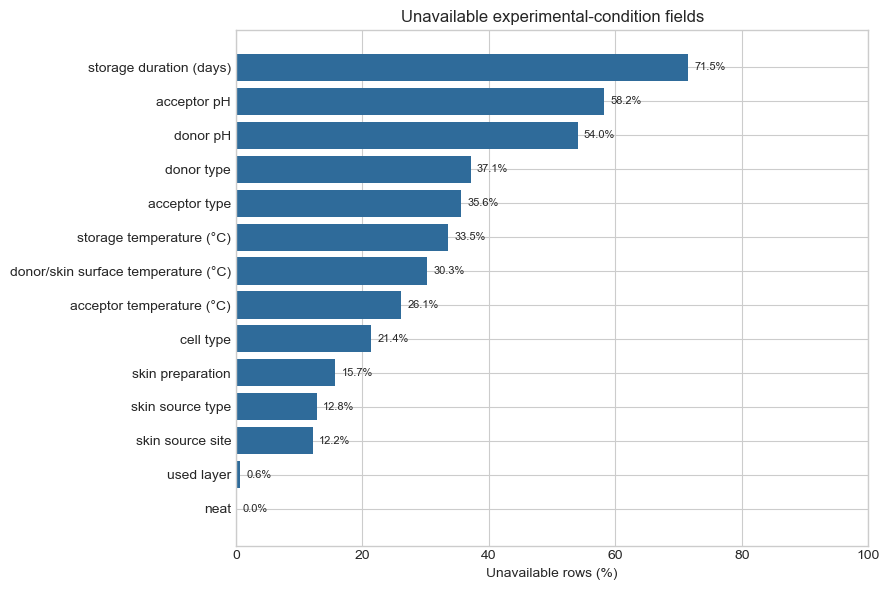

In [3]:
overall_condition_summary = pd.DataFrame({
    "Metric": [
        "Condition cells", "Available cells", "Unavailable cells", "Available percent",
        "Median unavailable fields per row", "Rows with all 14 fields", "Rows with at least 7 unavailable fields",
    ],
    "Value": [
        int(missing_mask.size), int((~missing_mask).to_numpy().sum()), int(missing_mask.to_numpy().sum()),
        float(100 * (~missing_mask).to_numpy().mean()), float(missing_mask.sum(axis=1).median()),
        int((missing_mask.sum(axis=1) == 0).sum()), int((missing_mask.sum(axis=1) >= 7).sum()),
    ],
})
display(overall_condition_summary)
display(condition_profile)

plot_data = condition_profile.sort_values("Unavailable_Percent")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_data["Field"], plot_data["Unavailable_Percent"], color="#2F6B9A")
ax.set_xlabel("Unavailable rows (%)")
ax.set_ylabel("")
ax.set_title("Unavailable experimental-condition fields")
ax.set_xlim(0, 100)
for y, value in enumerate(plot_data["Unavailable_Percent"]):
    ax.text(value + 1, y, f"{value:.1f}%", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "condition_missingness.png", dpi=300, bbox_inches="tight")
plt.show()

### 3. Reference and protocol effects cannot be separated cleanly

The subset includes 71 reference/DOI pairs published from 1964 to 2012. Coverage is broad: the five largest references contribute 22.3% of rows and the ten largest contribute 35.9%. However, every one of the 140 condition signatures occurs within only one reference, so laboratory/source effects are completely coupled to the recorded protocol signature in this subset.

,Metric,Value
0,Reference/DOI pairs,71.000000
1,Earliest year,1964.000000
2,Latest year,2012.000000
3,Top 5 row share (%),22.255193
4,Top 10 row share (%),35.905045
5,Condition signatures,140.000000
6,Signatures spanning multiple references,0.000000


,reference,DOI,DOI_URL,Selected_Measurements,Unique_Compounds,Condition_Signatures,Experimental_Min,Experimental_Max,Experimental_Range,Selected_Row_Share_Percent,Reference_Year
0,"Roberts, 1977",10.1111/j.2042-7158.1977.tb11434.x,https://doi.org/10.1111/j.2042-7158.1977.tb114...,18,18,1,-5.810,-4.778,1.032,5.341246,1977
1,"Scheuplein, 1973",10.1111/1523-1747.ep12723090,https://doi.org/10.1111/1523-1747.ep12723090,17,10,4,-6.857,-4.653,2.204,5.044510,1973
2,"Roy, 1990",10.1023/A:1015912932416,https://doi.org/10.1023/A:1015912932416,16,2,8,-5.849,-5.013,0.836,4.747774,1990
3,"Buist, 2010",10.1016/j.yrtph.2010.02.008,https://doi.org/10.1016/j.yrtph.2010.02.008,14,14,1,-7.653,-5.065,2.588,4.154303,2010
4,"Zhang, 2009",10.1007/s11095-009-9912-4,https://doi.org/10.1007/s11095-009-9912-4,10,10,1,-5.632,-4.651,0.981,2.967359,2009
5,"Chantasart, 2010",10.1007/s11095-010-0181-z,https://doi.org/10.1007/s11095-010-0181-z,10,8,2,-5.481,-4.810,0.671,2.967359,2010
6,"Sznitowska, 2001",10.1016/s0168-3659(01)00443-6,https://doi.org/10.1016/s0168-3659(01)00443-6,10,2,10,-7.681,-5.476,2.205,2.967359,2001
7,"Anderson, 1988",10.1023/a:1015989929342,https://doi.org/10.1023/a:1015989929342,9,7,2,-6.757,-5.824,0.933,2.670623,1988
8,"Cross, 2003",10.1046/j.1523-1747.2003.12131.x,https://doi.org/10.1046/j.1523-1747.2003.12131.x,9,5,3,-6.352,-4.586,1.766,2.670623,2003
9,"Mitragotri, 2000",10.1023/A:1007547809430,https://doi.org/10.1023/A:1007547809430,8,8,1,-8.079,-4.602,3.477,2.373887,2000


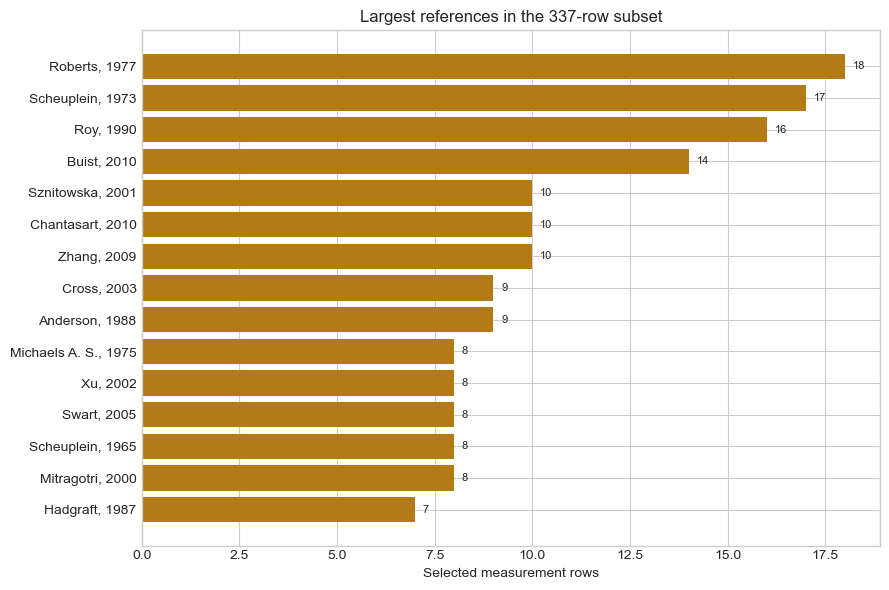

In [4]:
signature_reference = df.groupby("Condition_Signature")["reference"].nunique()
reference_summary = pd.DataFrame({
    "Metric": ["Reference/DOI pairs", "Earliest year", "Latest year", "Top 5 row share (%)", "Top 10 row share (%)",
               "Condition signatures", "Signatures spanning multiple references"],
    "Value": [len(reference), int(reference["Reference_Year"].min()), int(reference["Reference_Year"].max()),
              float(reference.head(5)["Selected_Measurements"].sum() / len(df) * 100),
              float(reference.head(10)["Selected_Measurements"].sum() / len(df) * 100),
              int(len(signature_reference)), int((signature_reference > 1).sum())],
})
display(reference_summary)
display(reference.head(15))

plot_refs = reference.head(15).sort_values("Selected_Measurements")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_refs["reference"], plot_refs["Selected_Measurements"], color="#B47A16")
ax.set_xlabel("Selected measurement rows")
ax.set_ylabel("")
ax.set_title("Largest references in the 337-row subset")
for y, value in enumerate(plot_refs["Selected_Measurements"]):
    ax.text(value + 0.2, y, str(int(value)), va="center", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "reference_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

### 4. Experimental variability is much wider than the model's condition response

Fifty-four compounds have repeated selected measurements. Their median experimental logKp range is 0.381, compared with a median prediction range of 0.0137; all repeated-compound prediction ranges are below 0.1. Twenty-two repeated compounds have exactly the same prediction for every selected row. This does not imply model failure by itself, but it shows that this LGBM configuration cannot reproduce most row-to-row protocol variability.

,Metric,Value
0,Single-measurement compounds,117.000000
1,Repeated-measurement compounds,54.000000
2,Repeated compounds with nonzero range,51.000000
3,Range >0.5 log unit,21.000000
4,Range >1.0 log unit,3.000000
5,Median experimental range,0.381000
6,Median prediction range,0.013676
7,Constant prediction across selected rows,22.000000
8,Maximum prediction range,0.083694


,Variability_Rank,Canonical_SMILES,Compound_Name,Selected_Measurements,Experimental_Min,Experimental_Max,Experimental_Mean,Experimental_Median,Experimental_SD,Predicted_Min,Predicted_Max,Condition_Signatures,References,DOIs,Experimental_Range,Experimental_Fold_Range_Kp,Predicted_Range,Variability_Band
0,1,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...,Estradiol,12,-6.684,-5.556,-6.039167,-5.9925,0.310639,-6.138216,-6.105572,12,10,10,1.128,13.427650,0.032644,High (>1.0 log unit)
1,2,CCCCO,1-Butanol,10,-6.556,-5.481,-6.041400,-6.1185,0.310107,-6.001375,-5.972489,10,8,8,1.075,11.885022,0.028886,High (>1.0 log unit)
2,3,Cn1c(=O)c2c(ncn2C)n(C)c1=O,Caffeine,6,-7.556,-6.541,-7.006333,-6.9840,0.340652,-6.963696,-6.923658,6,5,5,1.015,10.351422,0.040037,High (>1.0 log unit)
3,4,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)N[C@@H](CC...,Methotrexate,7,-7.503,-6.503,-6.926000,-6.8400,0.345937,-6.951581,-6.951581,6,1,1,1.000,10.000000,0.000000,Moderate (>0.5 to 1.0 log unit)
4,5,CCCCCCO,1-Hexanol,10,-5.778,-4.859,-5.275000,-5.2695,0.305366,-5.345842,-5.270181,10,5,5,0.919,8.298508,0.075661,Moderate (>0.5 to 1.0 log unit)
5,6,CCCCCCCCCCO,1-Decanol,4,-5.515,-4.602,-4.867750,-4.6770,0.433389,-5.063658,-4.986924,4,4,4,0.913,8.184648,0.076733,Moderate (>0.5 to 1.0 log unit)
6,7,CCC(=O)N(c1ccccc1)C1CCN(CCc2ccccc2)CC1,Fentanyl,10,-5.849,-5.013,-5.424600,-5.4775,0.314755,-5.520293,-5.510236,10,3,3,0.836,6.854882,0.010058,Moderate (>0.5 to 1.0 log unit)
7,8,CCO,Ethanol,7,-7.079,-6.278,-6.667429,-6.6530,0.312083,-6.557381,-6.490221,7,5,5,0.801,6.324119,0.067160,Moderate (>0.5 to 1.0 log unit)
8,9,O=C(O)c1ccccc1O,Salicylic acid,3,-6.216,-5.416,-5.797333,-5.7600,0.401305,-5.844099,-5.820967,3,3,3,0.800,6.309573,0.023132,Moderate (>0.5 to 1.0 log unit)
9,10,CN1CCCC1c1cccnc1,Nicotine,3,-6.036,-5.270,-5.617333,-5.5460,0.387950,-5.765490,-5.751475,3,3,3,0.766,5.834451,0.014014,Moderate (>0.5 to 1.0 log unit)


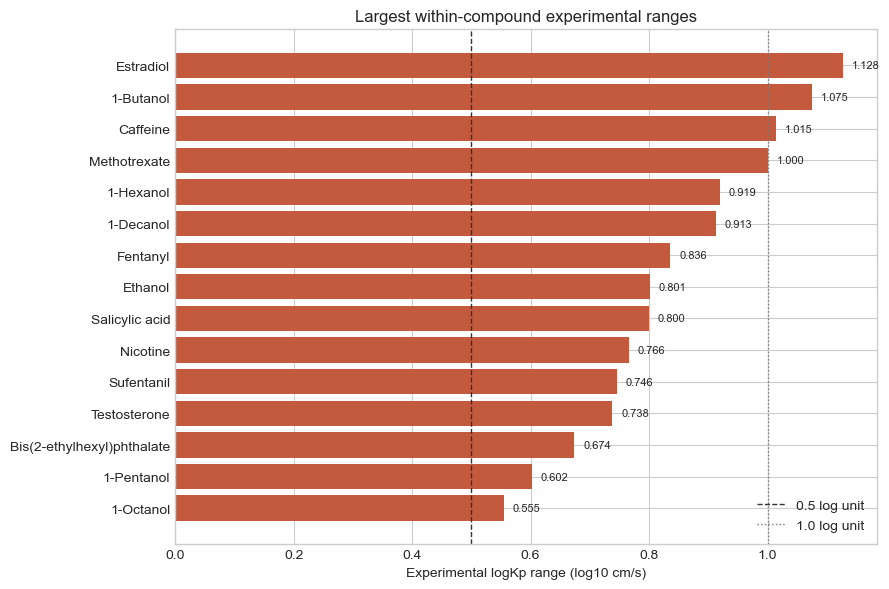

In [5]:
repeated = compound[compound["Selected_Measurements"] > 1].copy()
variability_summary = pd.DataFrame({
    "Metric": [
        "Single-measurement compounds", "Repeated-measurement compounds", "Repeated compounds with nonzero range",
        "Range >0.5 log unit", "Range >1.0 log unit", "Median experimental range", "Median prediction range",
        "Constant prediction across selected rows", "Maximum prediction range",
    ],
    "Value": [
        int((compound["Selected_Measurements"] == 1).sum()), len(repeated), int((repeated["Experimental_Range"] > 0).sum()),
        int((repeated["Experimental_Range"] > 0.5).sum()), int((repeated["Experimental_Range"] > 1.0).sum()),
        float(repeated["Experimental_Range"].median()), float(repeated["Predicted_Range"].median()),
        int(np.isclose(repeated["Predicted_Range"], 0).sum()), float(repeated["Predicted_Range"].max()),
    ],
})
display(variability_summary)
display(repeated.head(20))

plot_compounds = repeated.head(15).sort_values("Experimental_Range")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_compounds["Compound_Name"], plot_compounds["Experimental_Range"], color="#C45A3D")
ax.axvline(0.5, color="#333333", linestyle="--", linewidth=1, label="0.5 log unit")
ax.axvline(1.0, color="#777777", linestyle=":", linewidth=1, label="1.0 log unit")
ax.set_xlabel("Experimental logKp range (log10 cm/s)")
ax.set_ylabel("")
ax.set_title("Largest within-compound experimental ranges")
ax.legend(frameon=False, loc="lower right")
for y, value in enumerate(plot_compounds["Experimental_Range"]):
    ax.text(value + 0.015, y, f"{value:.3f}", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "compound_variability.png", dpi=300, bbox_inches="tight")
plt.show()

### 5. Same-reference series provide the clearest condition-linked examples

Within a single citation, methotrexate spans 1.000 log unit while donor pH changes; fentanyl and sufentanil each span roughly 0.75–0.84 log unit across the Roy (1990) pH series. These patterns are biologically plausible for ionizable compounds, but the observational table still contains co-varying preparation or medium fields and does not justify a causal estimate.

,Compound_Name,Canonical_SMILES,Reference,DOI,Measurements,Experimental_Min,Experimental_Max,Experimental_Range,Varying_Condition_Count,Varying_Conditions,Donor_pH_Spearman_Rho,Donor_pH_Spearman_P
0,Methotrexate,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(C(=O)N[C@@H](CC...,"Vaidyanathan, 1985",10.1016/0378-5173(85)90106-1,7,-7.503,-6.503,1.000,1,donor pH,0.612637,0.143589
1,Estradiol,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...,"Pershing, 1993",10.1023/A:1018974131236,2,-6.556,-5.556,1.000,1,donor type,NaN,NaN
2,Fentanyl,CCC(=O)N(c1ccccc1)C1CCN(CCc2ccccc2)CC1,"Roy, 1990",10.1023/A:1015912932416,8,-5.849,-5.013,0.836,5,skin source site | used layer | skin preparati...,0.976190,0.000033
3,Sufentanil,CCC(=O)N(c1ccccc1)C1(COC)CCN(CCc2cccs2)CC1,"Roy, 1990",10.1023/A:1015912932416,8,-5.764,-5.018,0.746,5,skin source site | used layer | skin preparati...,0.976190,0.000033
4,1-Hexanol,CCCCCCO,"Cross, 2003",10.1046/j.1523-1747.2003.12131.x,3,-5.778,-5.051,0.727,2,used layer | skin preparation,NaN,NaN
5,Estradiol,C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...,"Goodman, 1988",10.1111/1523-1747.ep12475655,2,-6.684,-6.018,0.666,2,donor type | acceptor type,NaN,NaN
6,1-Pentanol,CCCCCO,"Scheuplein, 1973",10.1111/1523-1747.ep12723090,2,-5.778,-5.176,0.602,1,used layer,NaN,NaN
7,Ephedrine,CN[C@@H](C)[C@H](O)c1ccccc1,"Michaels A. S., 1975",10.1002/aic.690210522,4,-6.326,-5.778,0.548,1,donor pH,0.774597,0.225403
8,Lysine,NCCCC[C@H](N)C(=O)O,"Sznitowska, 1993",10.1016/0378-5173(93)90321-6,2,-7.328,-6.860,0.468,1,donor pH,NaN,NaN
9,1-Butanol,CCCCO,"Scheuplein, 1973",10.1111/1523-1747.ep12723090,2,-6.556,-6.158,0.398,2,used layer | neat,NaN,NaN


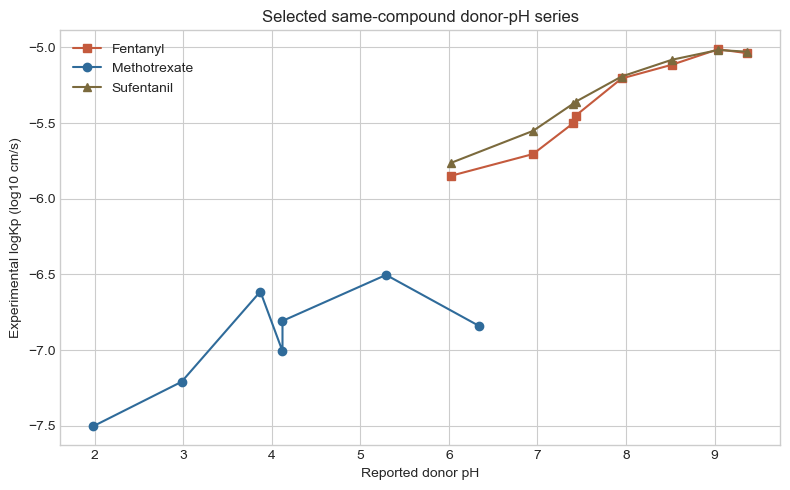

In [6]:
same_reference_rows = []
for (canonical, ref, doi), group in df.groupby([COMPOUND_KEY, "reference", "DOI"], dropna=False):
    if len(group) < 2:
        continue
    varying = [field for field in CONDITION_COLUMNS if group[field].astype(str).str.strip().nunique(dropna=False) > 1]
    donor_ph = pd.to_numeric(group["donor pH"], errors="coerce")
    valid_ph = donor_ph.notna() & group[EXPERIMENTAL].notna()
    rho = p_value = np.nan
    if valid_ph.sum() >= 3 and donor_ph[valid_ph].nunique() >= 3:
        rho, p_value = spearmanr(donor_ph[valid_ph], group.loc[valid_ph, EXPERIMENTAL])
    same_reference_rows.append({
        "Compound_Name": group["Compound name"].iloc[0],
        COMPOUND_KEY: canonical,
        "Reference": ref,
        "DOI": doi,
        "Measurements": len(group),
        "Experimental_Min": float(group[EXPERIMENTAL].min()),
        "Experimental_Max": float(group[EXPERIMENTAL].max()),
        "Experimental_Range": float(group[EXPERIMENTAL].max() - group[EXPERIMENTAL].min()),
        "Varying_Condition_Count": len(varying),
        "Varying_Conditions": " | ".join(varying),
        "Donor_pH_Spearman_Rho": rho,
        "Donor_pH_Spearman_P": p_value,
    })
same_reference = pd.DataFrame(same_reference_rows).sort_values(
    ["Experimental_Range", "Measurements"], ascending=False
).reset_index(drop=True)
display(same_reference.head(25))

ph_compounds = ["Methotrexate", "Fentanyl", "Sufentanil"]
ph_rows = df[
    ((df["Compound name"] == "Methotrexate") & (df["reference"] == "Vaidyanathan, 1985"))
    | (df["Compound name"].isin(["Fentanyl", "Sufentanil"]) & (df["reference"] == "Roy, 1990"))
].copy()
ph_rows["Donor_pH_numeric"] = pd.to_numeric(ph_rows["donor pH"], errors="coerce")
ph_rows = ph_rows[ph_rows["Donor_pH_numeric"].notna()].sort_values(["Compound name", "Donor_pH_numeric"])
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"Methotrexate": "#2F6B9A", "Fentanyl": "#C45A3D", "Sufentanil": "#7B6A3D"}
markers = {"Methotrexate": "o", "Fentanyl": "s", "Sufentanil": "^"}
for name, group in ph_rows.groupby("Compound name"):
    ax.plot(group["Donor_pH_numeric"], group[EXPERIMENTAL], marker=markers[name], color=colors[name], label=name)
ax.set_xlabel("Reported donor pH")
ax.set_ylabel("Experimental logKp (log10 cm/s)")
ax.set_title("Selected same-compound donor-pH series")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "donor_ph_series.png", dpi=300, bbox_inches="tight")
plt.show()

### 6. Minimum-versus-maximum rows identify which conditions changed

For each repeatedly measured compound, the following table pairs the selected rows with minimum and maximum experimental logKp and records the condition columns that differ. This is an audit aid, not a causal decomposition.

In [7]:
extreme_rows = []
for canonical, group in df.groupby(COMPOUND_KEY, dropna=False):
    if len(group) <= 1:
        continue
    low = group.loc[group[EXPERIMENTAL].idxmin()]
    high = group.loc[group[EXPERIMENTAL].idxmax()]
    differing = [field for field in CONDITION_COLUMNS if str(low[field]).strip() != str(high[field]).strip()]
    record = {
        "Compound_Name": low["Compound name"],
        COMPOUND_KEY: canonical,
        "Selected_Measurements": len(group),
        "Experimental_Min": low[EXPERIMENTAL],
        "Experimental_Max": high[EXPERIMENTAL],
        "Experimental_Range": high[EXPERIMENTAL] - low[EXPERIMENTAL],
        "Experimental_Fold_Range_Kp": 10 ** (high[EXPERIMENTAL] - low[EXPERIMENTAL]),
        "Predicted_Range": group[PREDICTED].max() - group[PREDICTED].min(),
        "Low_Source_Data_Row": int(low["Source_Data_Row"]),
        "High_Source_Data_Row": int(high["Source_Data_Row"]),
        "Low_Reference": low["reference"],
        "High_Reference": high["reference"],
        "Low_DOI": low["DOI"],
        "High_DOI": high["DOI"],
        "Differing_Condition_Count": len(differing),
        "Differing_Conditions": " | ".join(differing),
    }
    for field in CONDITION_COLUMNS:
        record[f"Low_{field}"] = low[field]
        record[f"High_{field}"] = high[field]
    extreme_rows.append(record)
variability_extremes = pd.DataFrame(extreme_rows).sort_values(
    ["Experimental_Range", "Selected_Measurements"], ascending=False
).reset_index(drop=True)
display(variability_extremes.head(15)[[
    "Compound_Name", "Selected_Measurements", "Experimental_Min", "Experimental_Max",
    "Experimental_Range", "Experimental_Fold_Range_Kp", "Predicted_Range",
    "Low_Reference", "High_Reference", "Differing_Conditions",
]])

,Compound_Name,Selected_Measurements,Experimental_Min,Experimental_Max,Experimental_Range,Experimental_Fold_Range_Kp,Predicted_Range,Low_Reference,High_Reference,Differing_Conditions
0,Estradiol,12,-6.684,-5.556,1.128,13.427650,0.032644,"Goodman, 1988","Pershing, 1993",skin source type | used layer | skin preparati...
1,1-Butanol,10,-6.556,-5.481,1.075,11.885022,0.028886,"Scheuplein, 1973","Chantasart, 2010",skin source type | used layer | storage temper...
2,Caffeine,6,-7.556,-6.541,1.015,10.351422,0.040037,"Mitragotri, 1995","Wilkinson, 2006",skin source type | skin source site | used lay...
3,Methotrexate,7,-7.503,-6.503,1.000,10.000000,0.000000,"Vaidyanathan, 1985","Vaidyanathan, 1985",donor pH
4,1-Hexanol,10,-5.778,-4.859,0.919,8.298508,0.075661,"Cross, 2003","Bond, 1988",skin source type | skin source site | skin pre...
5,1-Decanol,4,-5.515,-4.602,0.913,8.184648,0.076733,"Buist, 2010","Mitragotri, 2000",skin source site | skin preparation | storage ...
6,Fentanyl,10,-5.849,-5.013,0.836,6.854882,0.010058,"Roy, 1990","Roy, 1990",donor pH | donor type
7,Ethanol,7,-7.079,-6.278,0.801,6.324119,0.067160,"Blank, 1964","Cross, 2003",skin source type | used layer | skin preparati...
8,Salicylic acid,3,-6.216,-5.416,0.800,6.309573,0.023132,"Schmook, 2001","Degim, 1998",skin source type | skin preparation | storage ...
9,Nicotine,3,-6.036,-5.270,0.766,5.834451,0.014014,"Degim, 1998","Hadgraft, 1987",skin source type | skin preparation | storage ...


## Takeaways

1. Use `lgbm_337_rows_annotated.csv` for row-by-row review; it preserves the original conditions and citations and adds completeness and variability context.
2. Treat the 117 single-measurement compounds as having **unknown**, not low, experimental variability.
3. Use same-reference series—especially methotrexate, fentanyl, sufentanil, and ephedrine—as focused case studies, while retaining their co-varying-condition caveats.
4. Do not estimate a general skin-source, preparation, pH, temperature, donor-medium, or cell-type effect from this selected subset without a multilevel model on the full unfiltered HuSkinDB table.
5. For model improvement, represent pH/ionization, donor and receptor media, skin layer/preparation, storage, and cell type explicitly; the current LGBM condition input is limited to experimental temperature (`Texpi`).

In [8]:
# Save auditable outputs.
annotated.to_csv(OUTPUT_DIR / "lgbm_337_rows_annotated.csv", index=False, float_format="%.8f")
condition_profile.to_csv(OUTPUT_DIR / "lgbm_337_condition_profile.csv", index=False, float_format="%.8f")
reference.to_csv(OUTPUT_DIR / "lgbm_337_reference_summary.csv", index=False, float_format="%.8f")
compound.to_csv(OUTPUT_DIR / "lgbm_337_compound_variability.csv", index=False, float_format="%.8f")
same_reference.to_csv(OUTPUT_DIR / "lgbm_337_same_reference_series.csv", index=False, float_format="%.8f")
variability_extremes.to_csv(OUTPUT_DIR / "lgbm_337_variability_extremes.csv", index=False, float_format="%.8f")

summary = {
    "selected_rows": len(df),
    "unique_compounds": int(df[COMPOUND_KEY].nunique()),
    "single_measurement_compounds": int((compound["Selected_Measurements"] == 1).sum()),
    "repeated_compounds": int((compound["Selected_Measurements"] > 1).sum()),
    "repeated_range_gt_0_5": int((repeated["Experimental_Range"] > 0.5).sum()),
    "repeated_range_gt_1_0": int((repeated["Experimental_Range"] > 1.0).sum()),
    "median_experimental_range_repeated": float(repeated["Experimental_Range"].median()),
    "median_predicted_range_repeated": float(repeated["Predicted_Range"].median()),
    "references": int(df["reference"].nunique()),
    "condition_signatures": int(df["Condition_Signature"].nunique()),
    "condition_signatures_spanning_multiple_references": int((signature_reference > 1).sum()),
    "condition_cell_available_percent": float(100 * (~missing_mask).to_numpy().mean()),
}
(OUTPUT_DIR / "analysis_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

output_files = sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())
assert len(annotated) == 337
assert annotated["Absolute_Error_LGBM"].le(0.6 + np.finfo(float).eps).all()
assert len(compound) == 171
assert len(reference) == 71
print(json.dumps(summary, indent=2))
print("\nFiles in analysis directory:")
for name in output_files:
    print("-", name)

{
  "selected_rows": 337,
  "unique_compounds": 171,
  "single_measurement_compounds": 117,
  "repeated_compounds": 54,
  "repeated_range_gt_0_5": 21,
  "repeated_range_gt_1_0": 3,
  "median_experimental_range_repeated": 0.3809999999999998,
  "median_predicted_range_repeated": 0.013676309999999692,
  "references": 71,
  "condition_signatures": 140,
  "condition_signatures_spanning_multiple_references": 0,
  "condition_cell_available_percent": 70.79270877490463
}

Files in analysis directory:
- README.md
- analysis_summary.json
- compound_variability.png
- condition_missingness.png
- donor_ph_series.png
- lgbm_337_compound_variability.csv
- lgbm_337_condition_profile.csv
- lgbm_337_experimental_context_analysis.ipynb
- lgbm_337_reference_summary.csv
- lgbm_337_rows_annotated.csv
- lgbm_337_same_reference_series.csv
- lgbm_337_variability_extremes.csv
- reference_coverage.png
